# EDA for Top Spotify Songs in 73 Countries (Daily Updated) dataset.
- https://www.kaggle.com/datasets/asaniczka/top-spotify-songs-in-73-countries-daily-updated/versions/493
- Version 608

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

# Mina konstanter rörs ej (Skrivs med ALL CAPS i Python)
FILE_PATH = "../data/raw/universal_top_spotify_songs_Version_608.csv"

df = pd.read_csv(FILE_PATH)

In [2]:
# Utforska rader + kolumner
print("=== SHAPE (Rows, columns) ===")
print(df.shape)

=== SHAPE (Rows, columns) ===
(2110316, 25)


In [3]:
# Utforska datatyperna
print("\n=== DTYPES (Data types) ===")
print(df.dtypes)



=== DTYPES (Data types) ===
spotify_id                str
name                      str
artists                   str
daily_rank              int64
daily_movement          int64
weekly_movement         int64
country                   str
snapshot_date             str
popularity              int64
is_explicit              bool
duration_ms             int64
album_name                str
album_release_date        str
danceability          float64
energy                float64
key                     int64
loudness              float64
mode                    int64
speechiness           float64
acousticness          float64
instrumentalness      float64
liveness              float64
valence               float64
tempo                 float64
time_signature          int64
dtype: object


In [4]:
# Söka efter NULL values
print("\n=== NULL-VALUES (How much trash do I have?) ===")
print(df.isnull().sum())


=== NULL-VALUES (How much trash do I have?) ===
spotify_id                0
name                     30
artists                  29
daily_rank                0
daily_movement            0
weekly_movement           0
country               28908
snapshot_date             0
popularity                0
is_explicit               0
duration_ms               0
album_name              822
album_release_date      659
danceability              0
energy                    0
key                       0
loudness                  0
mode                      0
speechiness               0
acousticness              0
instrumentalness          0
liveness                  0
valence                   0
tempo                     0
time_signature            0
dtype: int64


In [5]:
# Första 3 rows
df.head(3)

,spotify_id,name,artists,daily_rank,daily_movement,weekly_movement,country,snapshot_date,popularity,is_explicit,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,2RkZ5LkEzeHGRsmDqKwmaJ,Ordinary,Alex Warren,1,1,0,NaN,2025-06-11,95,False,...,2,-6.141,1,0.0600,0.704000,0.000007,0.0550,0.391,168.115,3
1,42UBPzRMh5yyz0EDPr6fr1,Manchild,Sabrina Carpenter,2,-1,48,NaN,2025-06-11,89,True,...,7,-5.087,1,0.0572,0.122000,0.000000,0.3170,0.811,123.010,4
2,0FTmksd2dxiE5e3rWyJXs6,back to friends,sombr,3,0,1,NaN,2025-06-11,98,False,...,1,-2.291,1,0.0301,0.000094,0.000088,0.0929,0.235,92.855,4


## From raw data to cleaned and processed data. [Taking my insights from quick and basic EDA and processing that data](../docs/eda_insights/top_spotify_songs_countries.md)

In [13]:
# 1) Hantera saknade länder, NaN (Null values) -> Global
df['country'] = df['country'].fillna('Global')

# 2) Droppa de FÅ rader där artistnamn eller låtnamn saknas(Är 59stycken totalt. Irrelevant på 2.1miljoner)
df = df.dropna(subset=['name', 'artists'])

# 3) Konvertera datumsträng till riktiga DateTime objects.
# === KRITISKT FÖR TIDSANALYSEN ===
df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])

# 4) Skapa ny column med Månad för att underlätta för att analysera "säsongs trender"
df['month'] = df['snapshot_date'].dt.month

# 5) År och månad, ta ut t.ex, 2024-01, 2024-02 (bra för historiska tidslinjer)
df['year_month'] = df['snapshot_date'].dt.strftime('%Y-%m')

print("Cleaning done. New Null-Values:")
print(df.isnull().sum())

Cleaning done. New Null-Values:
spotify_id              0
name                    0
artists                 0
daily_rank              0
daily_movement          0
weekly_movement         0
country                 0
snapshot_date           0
popularity              0
is_explicit             0
duration_ms             0
album_name            792
album_release_date    630
danceability            0
energy                  0
key                     0
loudness                0
mode                    0
speechiness             0
acousticness            0
instrumentalness        0
liveness                0
valence                 0
tempo                   0
time_signature          0
month                   0
year_month              0
dtype: int64


## How far back does this dataset span? How many years or months?

In [14]:
print("How far back in time does this dataset go?\n\n")
print(f"Earliest date: {df['snapshot_date'].min().date()}")
print(f"Latest date:   {df['snapshot_date'].max().date()}")
print(f"Number of unique days: {df['snapshot_date'].nunique()}")

How far back in time does this dataset go?


Earliest date: 2023-10-18
Latest date:   2025-06-11
Number of unique days: 583


## Data is processed and cleaned for my use purposes. 
**What am I looking for?:**
- Is there ANY correlation with seasons and happiness in music?
    - Yes. There is. Happiness PEAKS in July and around Christmas.
- Is there ANY correlation with seasons and danceability in music?
    - Yes. There is. Danceability PEAKS in July
- is there ANY correlation with seasons and energy in music?
    - Yes there SEEMS to be. 



In [ ]:
# Filtrerar ut endast den globala datan
df_global = df[df["country"] == "Global"]

# 1. Gruppera på den NYA kolumnen (year_month)
monthly_mood_history = df_global.groupby("year_month")["valence"].mean().reset_index()

# ===== PLOTTING =====
fig, ax = plt.subplots(figsize=(12, 6)) # Gjorde den lite bredare för att få plats med alla datum

# Lineplot
sns.lineplot(
    data=monthly_mood_history,
    x="year_month", # Använder nya kolumnen här också
    y="valence",
    marker="o",
    color="#0B0B96",
    ax=ax,
    linewidth=2.5,
)

# Data storytelling
ax.set_title('Global Music Happiness: Historical Timeline (2023-2025)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year and Month', fontsize=12)
ax.set_ylabel('Average Valence (0 = Sad, 1 = Happy)', fontsize=12)

# VIKTIGT: Eftersom att det är många månader nu, roterar jag texten på X-axeln så den går att läsa
plt.xticks(rotation=45)

# Bort med spines och på med grid
ax.grid(True, linestyle='--', alpha=0.7) # Gjorde gridden lite snyggare
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Filtrerar ut endast den globala datan för att inte bli helt förvirrad av alla länder
df_global = df[df["country"] == "Global"]
# Gruppera på månad och få fram ett snitt på valence(glädjen)
monthly_danceability = df_global.groupby("year_month")["danceability"].mean().reset_index()

# ===== PLOTTING =====
# OOP-way av att plotta istället
fix, ax = plt.subplots(figsize=(10, 6))

# Lineplot
sns.lineplot(
    data=monthly_danceability,
    x="year_month",
    y="danceability",
    marker="o",
    color="#14BB24",
    ax=ax,
    linewidth=2,
)


# Data storytelling: Rensar bort onödigt skräp och gör allting tydligare
ax.set_title('Global Music Danceability: Historical Timeline (2023-2025)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year and Month', fontsize=12)
ax.set_ylabel('Avarage Danceability (0 = low Danceability, 1 = high Danceability)', fontsize=12)
# VIKTIGT: Eftersom att det är många månader nu, roterar jag texten på X-axeln så den går att läsa
plt.xticks(rotation=45)

# Bort med spines och på med grid
ax.grid(True, linestyle='--', alpha=0.7) # Gjorde gridden lite snyggare
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

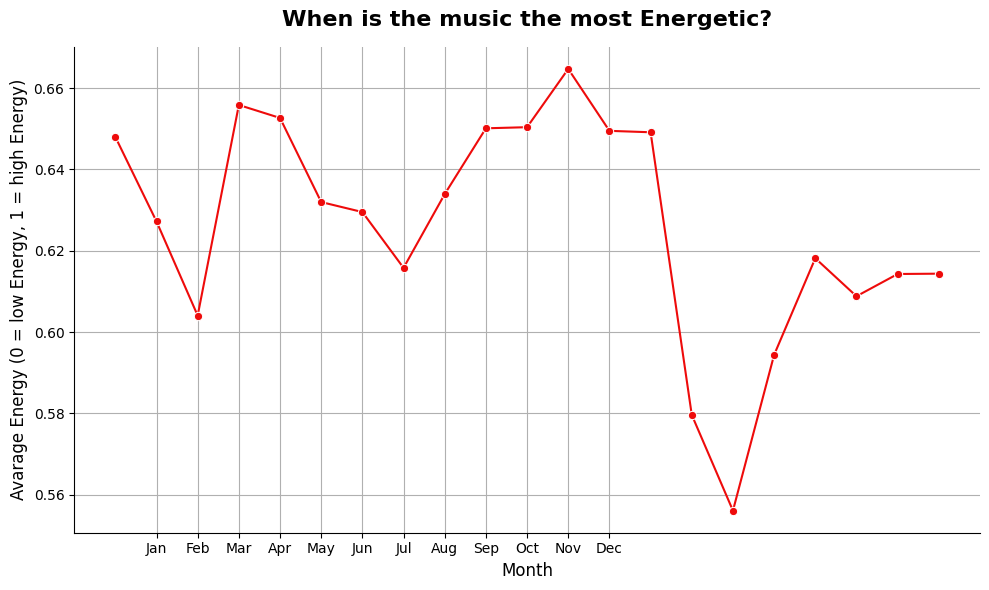

In [ ]:
# Filtrerar ut endast den globala datan för att inte bli helt förvirrad av alla länder
df_global = df[df["country"] == "Global"]
# Gruppera på månad och få fram ett snitt på valence(glädjen)
monthly_mood = df_global.groupby("month")["energy"].mean().reset_index()

# ===== PLOTTING =====
# OOP-way av att plotta istället
fix, ax = plt.subplots(figsize=(10, 6))

# Lineplot
sns.lineplot(
    data=monthly_mood,
    x="month",
    y="energy",
    marker="o",
    color="#EE0B0B",
    ax=ax,
    linewidth=2,
)

# Data storytelling: Rensar bort onödigt skräp och gör allting tydligare
ax.set_title('When is the music the most Energetic?', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Avarage Energy (0 = low Energy, 1 = high Energy)', fontsize=12)


# Bort med spines och få fram grid
ax.grid(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Insights from three diagrams meassuring Happiness(Valence), Danceability and Energy. 
- Three diagrams with two of them being a bit linked together but the energy diagram shows different and interesting numbers.
    - Time to create a plot for the three questions above and then a **heatmap** to try and find more insights.

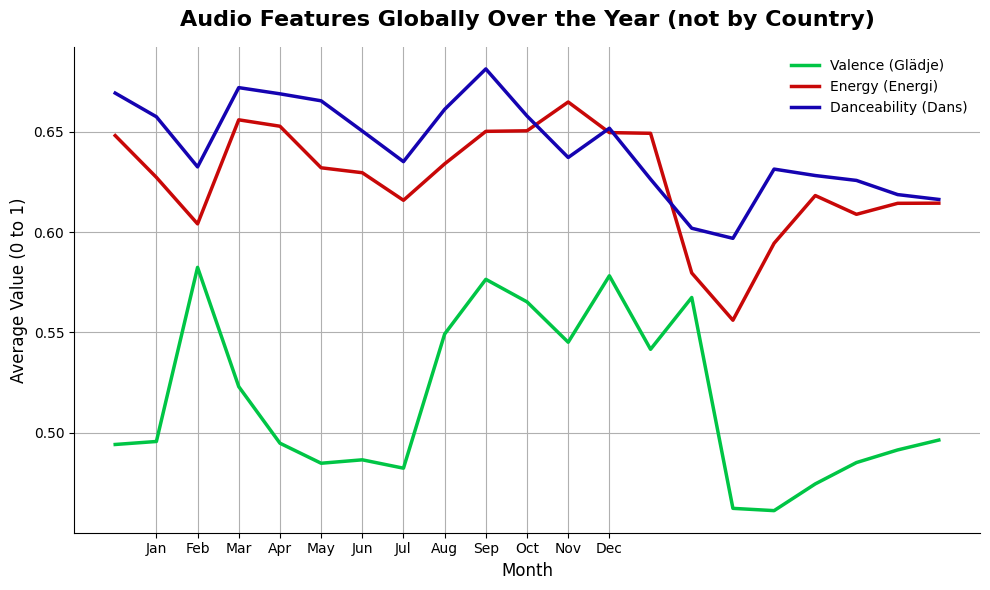

In [11]:
# Grupperar på månad och tar snittet för ALLA tre kolumner samtidigt(plots ovan denna)
monthly_metrics = df_global.groupby("month")[["valence", "energy", "danceability"]].mean().reset_index()

# Sätt upp grafen jag ska använda mig av
fig, ax = plt.subplots(figsize=(10, 6))

# Rita tre linjer på samma axel och ange tre olika färger för att se skillnaden
sns.lineplot(data=monthly_metrics, x="month", y="valence", label="Valence (Glädje)", color="#00C545", linewidth=2.5, ax=ax)
sns.lineplot(data=monthly_metrics, x="month", y="energy", label="Energy (Energi)", color="#C80808", linewidth=2.5, ax=ax)
sns.lineplot(data=monthly_metrics, x="month", y="danceability", label="Danceability (Dans)", color="#1503B1", linewidth=2.5, ax=ax)

# Formatering på hur jag vill att allting ska se ut.
ax.set_title('Audio Features Globally Over the Year (not by Country)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Value (0 to 1)', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# legend (förklaring) och ta bort ramar
ax.legend(frameon=False)
ax.grid(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

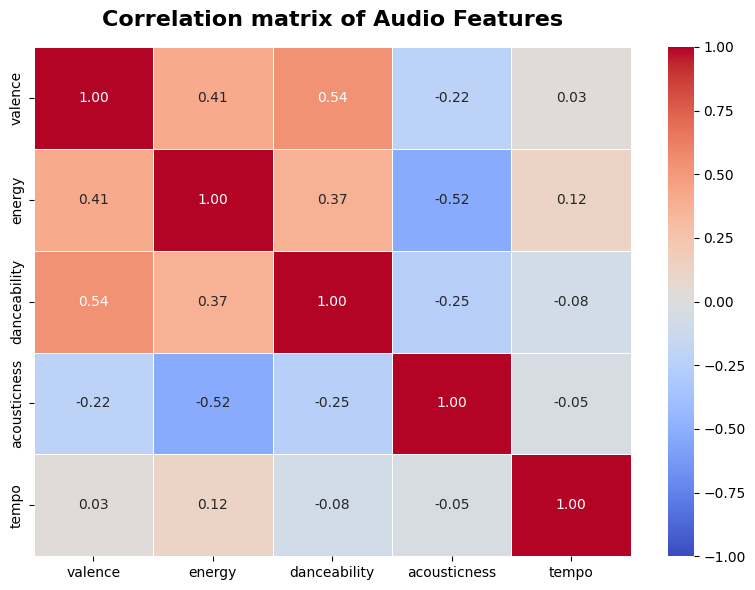

In [12]:
# Plocka bara ut de numeriska ljud kolumnerna ifrån datasettet
audio_cols = ["valence", "energy", "danceability", "acousticness", "tempo"]
df_audio = df_global[audio_cols]

# Räkna ut korrelationsmatrisen
correlation_matrix = df_audio.corr()

# Plotta en Heatmap med Seaborn 
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", linewidths=0.5, ax=ax)

ax.set_title('Correlation matrix of Audio Features', fontsize=16, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

## Time to save entire dataset.
- Choosing to write it in .parquet format for faster reading and smaller filesize.

In [14]:
# Spara HELA det städade datasettet.
processed_path = "../data/processed/spotify_daily_top_songs_clean_version608.parquet"

# index=False är viktigt för att INTE spara pandas onödiga radnummer
df.to_parquet(processed_path, index=False)

print(f"Done. Raw data processed and saved safetly in processed folder: {processed_path}")

Done. Raw data processed and saved safetly in processed folder: ../data/processed/spotify_daily_top_songs_clean_version608.parquet


In [15]:
PARQUET_FILE = "../data/processed/spotify_daily_top_songs_clean_version608.parquet"

query = f"""--sql
SELECT 
    MIN(snapshot_date) as earliest_date,
    MAX(snapshot_date) as latest_date,
    COUNT(DISTINCT snapshot_date) as total_days
FROM '{PARQUET_FILE}'
"""

time_check = duckdb.query(query).df()
print(time_check)

  earliest_date latest_date  total_days
0    2023-10-18  2025-06-11         583


In [16]:
# SQL query som streamar data direkt från filen.
# Utesluter "Global" för att bara titta på specifika länder.
query = """--sql
SELECT 
    country,
    COUNT(DISTINCT spotify_id) as unique_songs_played,
    AVG(danceability) as avg_danceability,
    AVG(energy) as avg_energy
FROM '../data/processed/spotify_daily_top_songs_clean_version608.parquet'
WHERE country != 'Global'
GROUP BY country
ORDER BY avg_danceability DESC
LIMIT 25;
"""

# duckdb.query() kör SQL och .df() konverterar svaret till en Pandas DataFrame
top_dance_countries = duckdb.query(query).df()

print("The worlds 10 most danceable countries according to Spotifys dataset:")
print(top_dance_countries)

The worlds 10 most danceable countries according to Spotifys dataset:
   country  unique_songs_played  avg_danceability  avg_energy
0       EC                  518          0.742231    0.676042
1       RO                  874          0.741016    0.721106
2       CO                  635          0.740255    0.670114
3       PE                  439          0.735960    0.680933
4       SV                  572          0.735182    0.681357
5       CL                  597          0.733264    0.676809
6       MX                  495          0.730464    0.691447
7       GT                  443          0.727031    0.685323
8       VE                  768          0.726504    0.667210
9       HN                  576          0.725330    0.680386
10      NI                  595          0.723650    0.669144
11      NG                  756          0.721751    0.677987
12      ZA                  909          0.721111    0.619245
13      HU                  696          0.719840    0.674900
